<a href="https://colab.research.google.com/github/katze-a0/Basic-cpp-problems/blob/main/detections_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!cp -r /content/drive/MyDrive/dataset_building.zip /content
#cp source destination
# !cp -r /content/drive/MyDrive/Nakkhu_Limited_Dataset /content

In [6]:
!cp -r /content/dataset_building.zip /content/custom_data

In [7]:
# Unzip images to a custom data folder
!unzip -q /content/dataset_building.zip -d /content/custom_data

replace /content/custom_data/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_data/notes.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_data/images/00c269bc-tile_img_0_1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [8]:
import os
import glob
import cv2
import albumentations as A
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- CONFIGURATION ---
INPUT_DIR = "custom_data"
OUTPUT_DIR = "augmented_dataset"
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# 1. Update transforms to include OBB-safe rotations
transforms = [
    None, # Original
    A.HorizontalFlip(p=1),
    A.VerticalFlip(p=1),
    A.RandomRotate90(p=1),
    A.Compose([A.RandomRotate90(p=1), A.HorizontalFlip(p=1)]),
    A.Compose([A.RandomRotate90(p=1), A.VerticalFlip(p=1)]),
    A.Transpose(p=1),
    A.RandomBrightnessContrast(p=1)
]

def load_yolo_obb(label_path):
    bboxes = []
    class_labels = []
    if not os.path.exists(label_path): return [], []
    with open(label_path, 'r') as f:
        for line in f:
            parts = list(map(float, line.split()))
            if len(parts) < 9: continue # class_id + 8 coordinates

            class_labels.append(int(parts[0]))
            # Fix: Extract all 8 coordinates instead of trying to find cx, cy, etc.
            bboxes.append(parts[1:9])
    return bboxes, class_labels

def save_yolo_obb(path, bboxes, class_labels):
    with open(path, 'w') as f:
        for cls, bbox in zip(class_labels, bboxes):
            # Ensure bbox is a flat list of 8 floats
            bbox_flattened = [float(coord) for point in bbox for coord in point] if isinstance(bbox[0], (list, tuple, np.ndarray)) else bbox
            bbox_str = " ".join([f"{coord:.6f}" for coord in bbox_flattened])
            f.write(f"{cls} {bbox_str}\n")

# Setup Folders
for s in ['train', 'val', 'test']:
    for t in ['images', 'labels']:
        os.makedirs(os.path.join(OUTPUT_DIR, s, t), exist_ok=True)

# 2. Process Images
img_paths = glob.glob(f"{INPUT_DIR}/images/*.png") + glob.glob(f"{INPUT_DIR}/images/*.jpg")
all_pairs = []

print(f"Augmenting {len(img_paths)} images...")
for img_p in tqdm(img_paths):
    img = cv2.imread(img_p)
    if img is None: continue
    h, w = img.shape[:2]
    name = os.path.basename(img_p).split('.')[0]
    lbl_p = os.path.join(INPUT_DIR, 'labels', f"{name}.txt")

    orig_bboxes, class_labels = load_yolo_obb(lbl_p)

    for i, tr in enumerate(transforms):
        aug_name = f"{name}_aug{i}"
        if tr is None:
            aug_img, aug_bboxes = img.copy(), orig_bboxes
        else:
            aug = A.Compose([tr], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

            # Reshape 8 values into 4 pairs of (x, y)
            kp_list = [np.array(b).reshape(4, 2) for b in orig_bboxes]
            flat_kps = [item for sublist in kp_list for item in sublist]

            # Convert normalized to pixel coordinates
            pixel_kps = [(k[0]*w, k[1]*h) for k in flat_kps]

            transformed = aug(image=img, keypoints=pixel_kps)
            aug_img = transformed['image']

            # Re-normalize and group back to 8-value format
            new_kps = [(k[0]/w, k[1]/h) for k in transformed['keypoints']]
            aug_bboxes = [new_kps[j:j+4] for j in range(0, len(new_kps), 4)]

        all_pairs.append((aug_img, aug_bboxes, class_labels, aug_name))

# 3. Split and Save
train_data, temp_data = train_test_split(all_pairs, train_size=TRAIN_RATIO, random_state=42)
val_data, test_data = train_test_split(temp_data, train_size=0.5, random_state=42)

def save_set(data_list, split):
    print(f"Saving {split} set...")
    for img, bboxes, labels, name in tqdm(data_list):
        cv2.imwrite(os.path.join(OUTPUT_DIR, split, 'images', f"{name}.jpg"), img)
        save_yolo_obb(os.path.join(OUTPUT_DIR, split, 'labels', f"{name}.txt"), bboxes, labels)

save_set(train_data, 'train')
save_set(val_data, 'val')
save_set(test_data, 'test')

print(f"\nSuccess! Augmented dataset created in '{OUTPUT_DIR}'")

Augmenting 62 images...


  0%|          | 0/62 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for keypoints, but no transform to process it.
  self._set_keys()
100%|██████████| 62/62 [00:01<00:00, 39.76it/s]


Saving train set...


100%|██████████| 396/396 [00:00<00:00, 625.71it/s]


Saving val set...


100%|██████████| 50/50 [00:00<00:00, 646.71it/s]


Saving test set...


100%|██████████| 50/50 [00:00<00:00, 641.61it/s]


Success! Augmented dataset created in 'augmented_dataset'


In [9]:
!ls -1 augmented_dataset/train/images | grep -E "\.(jpg|png|jpeg)$" | wc -l

396


##Dataset Ready

In [16]:
# Copy classes.txt
!cp "custom_data/classes.txt" "augmented_dataset/classes.txt"

# Copy notes.json
!cp "custom_data/notes.json" "augmented_dataset/notes.json"

In [17]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/augmented_dataset',
      'train': 'train/images',
      'val': 'val/images',
      'test':'test/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/augmented_dataset/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/augmented_dataset
train: train/images
val: val/images
test: test/images
nc: 1
names:
- Residence


#Building a model (training from dataset)


In [18]:
!pip uninstall -y ultralytics
!pip install ultralytics


Found existing installation: ultralytics 8.4.84
Uninstalling ultralytics-8.4.84:
  Successfully uninstalled ultralytics-8.4.84
  Using cached ultralytics-8.4.84-py3-none-any.whl.metadata (41 kB)
Using cached ultralytics-8.4.84-py3-none-any.whl (1.3 MB)


In [19]:
from ultralytics import YOLO
import os

# Verify installation
print("YOLO imported successfully!")

# 1. Load the model
model = YOLO('yolov8n-obb.pt')

# 2. Train
model.train(
    data='/content/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    name='building_detector_v1'
)

YOLO imported successfully!
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=building_detector_v1-3, nbs=64, nms=False, opset=None, optimize=False, opti

ultralytics.utils.metrics.OBBMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e80c2b45df0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

##Checking trained model accuracy on unseen image

In [ ]:
!cat /content/runs/obb/building_detector_v1/weights/best.pt

Streaming output truncated to the last 5000 lines.
*�C���Ϊ����%�d��'��Ѩ )%D�9��!�(ȧx��x��P��(�?�C��-P�h��x�T3���K����%�%J i�B� %�y���{*%ʔ�)���(�"L/c'�'���B!��$&���*.��קK����$a-i*F��$��X�Y�ݥA�{,�
:'#�$���i��(���q�(�G�ˮ-�'+,���"q�&�
ٮf�d$$["�W�^��⢛�4�ĥ���ǯ�a$<'1!����$��z��,�(�w%�"��h�+��0�����.!�-F()�/(�-�0=�%�&r��&�	%(�����T�(�#������J����x���d���R�9�����!p�� ��إ���ͫ2N�N���[�c���= �!�Z�=�G�P����"�t%©N�(o#��B�&�˥_��+�����l�$�'�&��)-���)�,��A�����'��*�Π?����!
*$¡�,�(e%��̡s�ҥӨЦS#g(��6(�(�%$$����*�%�$v$�)/�'(ߝ-�+���6��#�,
)F������2��B�������䨰0Y,#٢g�E�L��3��,h)a����('�/�q��&����&�"�#��(Ȭ�!s#*�'0+�%l�i,J��(�$Q��(ū��Р�&�-���&f�%ޣ�$ܡ��К�)��ۤ��ōf�g��Z������>&��>�Ɣ������, (~,$.�(|�U���ר[){&��'��#�'-��v(%@������$g�W(ɦV��'��v&�����k������+�,�#*�#U,�z�ϣt��� K�b�f�p%ޥ���Q�#ʟ�Щ~�_+0(g�'$� ��+�.*u��(2���
 ����x�$���c(� Y�"�I���T&!®���1.������+&ਖ�  ���$D,([$���(%��ߥ1(J��)S#
�h+�(�&1,�&�)�^ Z$>��� 

###saving detections or output file

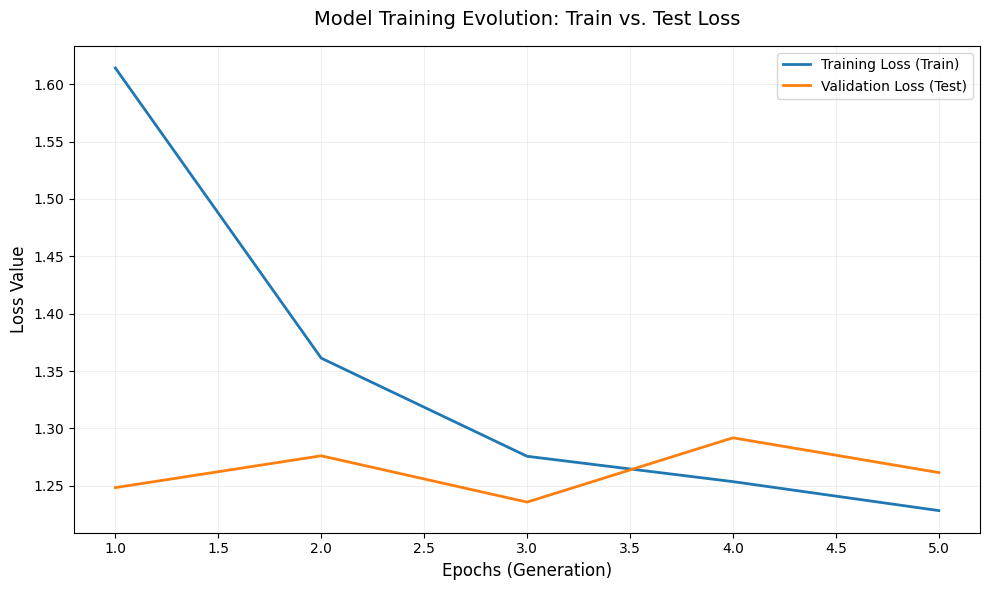

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the training data
# Replace 'results.csv' with the actual path to your YOLO results file
results = pd.read_csv('/content/runs/obb/building_detector_v1/results.csv')

# Clean column names (YOLO often adds extra spaces)
results.columns = [c.strip() for c in results.columns]

# 2. Setup the plot style
plt.figure(figsize=(10, 6), dpi=100)
plt.grid(True, which='both', linestyle='-', alpha=0.2)

# 3. Plot Training Loss and Validation Loss
# We use 'train/box_loss' as a proxy for 'Best' and 'val/box_loss' for 'Average'
# or you can plot total loss if available.
plt.plot(results['epoch'], results['train/box_loss'], label='Training Loss (Train)', color='#1f77b4', linewidth=2)
plt.plot(results['epoch'], results['val/box_loss'], label='Validation Loss (Test)', color='#ff7f0e', linewidth=2)

# 4. Add labels and title
plt.title('Model Training Evolution: Train vs. Test Loss', fontsize=14, pad=15)
plt.xlabel('Epochs (Generation)', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right', frameon=True)

# 5. Save and Show
plt.tight_layout()
plt.savefig('train_test_loss_comparison.png')
plt.show()

In [ ]:
##save coordinates- advanced
#donot run this cell
import cv2
import os
import glob
import shutil
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm

# --- 1. CLEANUP & SETUP ---
root_folder = 'Nakkhu_Building_Analytics'
input_folder = '/content/drive/MyDrive/Nakkhu_Dataset_Final/jpg_tiles'

# Reset the root folder
if os.path.exists(root_folder):
    shutil.rmtree(root_folder)
    print(f" Cleaned root folder: {root_folder}")

os.makedirs(root_folder, exist_ok=True)

# --- 2. LOAD MODEL ---
model = YOLO('/content/runs/obb/building_detector_v1/weights/best.pt')

# --- 3. PROCESS TILES ---
image_paths = glob.glob(os.path.join(input_folder, "*.jpg"))

if not image_paths:
    print(f" No images found in {input_folder}. Check path/extensions.")
else:
    print(f" Processing {len(image_paths)} tiles into individual folders...")

    for image_path in tqdm(image_paths):
        image_basename = os.path.basename(image_path)
        filename_no_ext = os.path.splitext(image_basename)[0]

        # Create a specific subfolder for this tile
        tile_subfolder = os.path.join(root_folder, filename_no_ext)
        os.makedirs(tile_subfolder, exist_ok=True)

        # Run OBB Inference
        results = model.predict(source=image_path, conf=0.3, verbose=False)

        building_data = []

        for result in results:
            # Save the annotated JPG inside the subfolder
            annotated_image = result.plot()
            cv2.imwrite(os.path.join(tile_subfolder, f"detection_{image_basename}"), annotated_image)

            if result.obb is not None:
                centers = result.obb.xywhr.cpu().numpy()
                corners = result.obb.xyxyxyxy.cpu().numpy()
                confs = result.obb.conf.cpu().numpy()
                classes = result.obb.cls.cpu().numpy()

                for i in range(len(centers)):
                    row = {
                        'class_id': int(classes[i]),
                        'confidence': round(float(confs[i]), 3),
                        'center_x': round(float(centers[i][0]), 2),
                        'center_y': round(float(centers[i][1]), 2),
                        'top_left_x': round(float(corners[i][0][0]), 2),
                        'top_left_y': round(float(corners[i][0][1]), 2),
                        'top_right_x': round(float(corners[i][1][0]), 2),
                        'top_right_y': round(float(corners[i][1][1]), 2),
                        'bottom_right_x': round(float(corners[i][2][0]), 2),
                        'bottom_right_y': round(float(corners[i][2][1]), 2),
                        'bottom_left_x': round(float(corners[i][3][0]), 2),
                        'bottom_left_y': round(float(corners[i][3][1]), 2)
                    }
                    building_data.append(row)

        # Save the CSV inside the subfolder
        if building_data:
            df = pd.DataFrame(building_data)
            csv_path = os.path.join(tile_subfolder, f"{filename_no_ext}_analytics.csv")
            df.to_csv(csv_path, index=False)
        else:
            # Create an empty file or log if no buildings detected
            with open(os.path.join(tile_subfolder, "no_detections.txt"), "w") as f:
                f.write("No buildings detected in this tile.")

    print(f"\n Done! Root folder '{root_folder}' now contains {len(image_paths)} subfolders.")



🗑️ Cleaned root folder: Nakkhu_Building_Analytics
🚀 Processing 1200 tiles into individual folders...


100%|██████████| 1200/1200 [01:00<00:00, 19.92it/s]


✅ Done! Root folder 'Nakkhu_Building_Analytics' now contains 1200 subfolders.


In [ ]:
# ##.tif to png file coordinate mapping
# # Run the function
# get_geo_coordinates_utm(tif_path, centers_file, output_csv)
#donot run this cell
import os
import glob
import pandas as pd
import rasterio
from rasterio.warp import transform
from tqdm import tqdm

# --- 1. CONFIGURATION ---
analytics_root = '/content/Nakkhu_Building_Analytics'
tif_folder = '/content/Nakkhu_Dataset_Final/tif_tiles'
target_crs = 'EPSG:32645'  # UTM Zone 45N

# --- 2. BATCH PROCESSING ---
# Get all subfolders (each represents one tile unit)
subfolders = [f.path for f in os.scandir(analytics_root) if f.is_dir()]

print(f" Found {len(subfolders)} tile units. Mapping pixel coordinates to UTM...")

for folder in tqdm(subfolders):
    tile_name = os.path.basename(folder)

    # Identify required files
    tif_path = os.path.join(tif_folder, f"{tile_name}.tif")
    analytics_csv_path = os.path.join(folder, f"{tile_name}_analytics.csv")
    geo_output_path = os.path.join(folder, f"{tile_name}_geo_locations.csv")

    # Skip if essential source files are missing
    if not os.path.exists(tif_path) or not os.path.exists(analytics_csv_path):
        continue

    # 3. COORDINATE TRANSFORMATION
    with rasterio.open(tif_path) as src:
        affine = src.transform
        native_crs = src.crs

        # Load the building detections
        df = pd.read_csv(analytics_csv_path)
        geo_results = []

        for _, row in df.iterrows():
            # Get pixel center
            px_x, px_y = row['center_x'], row['center_y']

            # Step A: Pixel to Native Map Coordinates (Affine Transformation)
            map_x, map_y = affine * (px_x, px_y)

            # Step B: Transform to UTM if necessary
            if native_crs.to_epsg() == 32645:
                utm_x, utm_y = map_x, map_y
            else:
                eastings, northings = transform(native_crs, target_crs, [map_x], [map_y])
                utm_x, utm_y = eastings[0], northings[0]

            # Step C: Collect geo-data for this building
            geo_results.append({
                'class_id': row['class_id'],
                'easting_utm_x': round(utm_x, 3),
                'northing_utm_y': round(utm_y, 3),
                'confidence': row['confidence']
            })

        # 4. SAVE NEW GEO FILE
        if geo_results:
            geo_df = pd.DataFrame(geo_results)
            geo_df.to_csv(geo_output_path, index=False)

print(f"\n Success! Each subfolder in '{analytics_root}' now contains a '_geo_locations.csv' file.")

🌍 Found 1200 tile units. Mapping pixel coordinates to UTM...


100%|██████████| 1200/1200 [00:00<00:00, 158245.76it/s]


✅ Success! Each subfolder in '/content/Nakkhu_Building_Analytics' now contains a '_geo_locations.csv' file.


In [22]:
##analytics ko pura kaam
import cv2
import os
import glob
import shutil
import pandas as pd
import rasterio
from rasterio.warp import transform
from ultralytics import YOLO
from tqdm import tqdm

# --- 1. CONFIGURATION ---
root_folder = '/content/Nakkhu_Building_Analytics_Paper'
input_jpg_folder = '/content/drive/MyDrive/Nakkhu_Dataset_Final/jpg_tiles'
input_tif_folder = '/content/drive/MyDrive/Nakkhu_Dataset_Final/tif_tiles'
model_path = '/content/runs/obb/building_detector_v1/weights/best.pt'
target_crs = 'EPSG:32645'  # UTM Zone 45N

# Cleanup & Setup
if os.path.exists(root_folder): shutil.rmtree(root_folder)
os.makedirs(root_folder, exist_ok=True)

# Load Model
model = YOLO(model_path)
image_paths = glob.glob(os.path.join(input_jpg_folder, "*.jpg"))

print(f" Starting Unified Pipeline: {len(image_paths)} tiles to process...")

# --- 2. THE UNIFIED LOOP ---
for image_path in tqdm(image_paths):
    image_basename = os.path.basename(image_path)
    filename_no_ext = os.path.splitext(image_basename)[0]

    # Define paths for this specific tile
    tile_subfolder = os.path.join(root_folder, filename_no_ext)
    tif_path = os.path.join(input_tif_folder, f"{filename_no_ext}.tif")

    os.makedirs(tile_subfolder, exist_ok=True)

    # A. YOLO OBB Inference
    results = model.predict(source=image_path, conf=0.3, verbose=False)

    building_pixel_data = []

    for result in results:
        # Save Annotated JPG
        annotated_image = result.plot()
        cv2.imwrite(os.path.join(tile_subfolder, f"detection_{image_basename}"), annotated_image)

        if result.obb is not None:
            centers = result.obb.xywhr.cpu().numpy()
            corners = result.obb.xyxyxyxy.cpu().numpy()
            confs = result.obb.conf.cpu().numpy()
            classes = result.obb.cls.cpu().numpy()

            for i in range(len(centers)):
                building_pixel_data.append({
                    'class_id': int(classes[i]),
                    'confidence': round(float(confs[i]), 3),
                    'center_x': round(float(centers[i][0]), 2),
                    'center_y': round(float(centers[i][1]), 2),
                    'top_left_x': round(float(corners[i][0][0]), 2),
                    'top_left_y': round(float(corners[i][0][1]), 2)
                })

    # B. Generate Pixel CSV & Geo CSV
    if building_pixel_data and os.path.exists(tif_path):
        # Save Pixel CSV
        pixel_df = pd.DataFrame(building_pixel_data)
        pixel_df.to_csv(os.path.join(tile_subfolder, f"{filename_no_ext}_analytics.csv"), index=False)

        # Geolocation Processing (UTM Mapping)
        with rasterio.open(tif_path) as src:
            affine = src.transform
            native_crs = src.crs
            geo_results = []

            for _, row in pixel_df.iterrows():
                # Pixel -> Native Map Coordinates
                map_x, map_y = affine * (row['center_x'], row['center_y'])

                # Native -> UTM 45N
                if native_crs.to_epsg() != 32645:
                    e, n = transform(native_crs, target_crs, [map_x], [map_y])
                    utm_x, utm_y = e[0], n[0]
                else:
                    utm_x, utm_y = map_x, map_y

                geo_results.append({
                    'class_id': row['class_id'],
                    'easting_utm_x': round(utm_x, 3),
                    'northing_utm_y': round(utm_y, 3),
                    'confidence': row['confidence']
                })

            # Save Geo CSV
            pd.DataFrame(geo_results).to_csv(os.path.join(tile_subfolder, f"{filename_no_ext}_geo_locations.csv"), index=False)

    elif not building_pixel_data:
        with open(os.path.join(tile_subfolder, "no_detections.txt"), "w") as f:
            f.write("No buildings detected.")

print(f"\n All tasks finished. Check the '{root_folder}' folder.")

 Starting Unified Pipeline: 1200 tiles to process...


100%|██████████| 1200/1200 [02:44<00:00,  7.30it/s]


 All tasks finished. Check the '/content/Nakkhu_Building_Analytics_Paper' folder.


In [ ]:
###adding class
import cv2
import os
import glob
import shutil
import pandas as pd
import rasterio
from rasterio.warp import transform
from ultralytics import YOLO
from tqdm import tqdm

# --- 1. CONFIGURATION ---
root_folder       = '/content/Nakkhu_Building_Analytics_Paper01'
input_jpg_folder  = '/content/drive/MyDrive/Nakkhu_Dataset_Final/jpg_tiles'
input_tif_folder  = '/content/drive/MyDrive/Nakkhu_Dataset_Final/tif_tiles'
model_path        = '/content/runs/obb/building_detector_v1/weights/best.pt'
target_crs        = 'EPSG:32645'

# Thresholds — tune these first
CONF_THRESHOLD    = 0.55   # raised from 0.3 → kills most vegetation FP
IOU_THRESHOLD     = 0.3    # NMS: lower = suppress more overlaps
MIN_AREA_PX       = 400    # ignore tiny detections (noise/vegetation specks)
MAX_AREA_PX       = 80000  # ignore huge blobs (not buildings)

# Class definitions — update to match YOUR model's trained classes
# If model has 1 class: {0: 'building'}
# If model has 2 classes: {0: 'residential', 1: 'commercial'}
CLASS_NAMES = {
    0: 'res',
    1:'commercial'# ← change if your model has more classes
}

# Cleanup & Setup
if os.path.exists(root_folder): shutil.rmtree(root_folder)
os.makedirs(root_folder, exist_ok=True)

model = YOLO(model_path)
image_paths = glob.glob(os.path.join(input_jpg_folder, "*.jpg"))
print(f"Starting pipeline: {len(image_paths)} tiles...")
print(f"Model classes: {model.names}\n")   # ← shows what classes model actually knows

# --- 2. HELPER: area filter ---
def box_area(corners):
    """Approximate bounding box area from OBB corners."""
    xs = corners[:, 0]
    ys = corners[:, 1]
    return (xs.max() - xs.min()) * (ys.max() - ys.min())

# --- 3. UNIFIED LOOP ---
for image_path in tqdm(image_paths):
    image_basename   = os.path.basename(image_path)
    filename_no_ext  = os.path.splitext(image_basename)[0]
    tile_subfolder   = os.path.join(root_folder, filename_no_ext)
    tif_path         = os.path.join(input_tif_folder, f"{filename_no_ext}.tif")
    os.makedirs(tile_subfolder, exist_ok=True)

    # A. Inference with tighter thresholds
    results = model.predict(
        source=image_path,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False
    )

    building_pixel_data = []

    for result in results:
        annotated = result.plot()
        cv2.imwrite(os.path.join(tile_subfolder, f"detection_{image_basename}"), annotated)

        if result.obb is None:
            continue

        centers = result.obb.xywhr.cpu().numpy()
        corners = result.obb.xyxyxyxy.cpu().numpy()
        confs   = result.obb.conf.cpu().numpy()
        classes = result.obb.cls.cpu().numpy()

        for i in range(len(centers)):
            area = box_area(corners[i])

            # Filter by area to remove vegetation/noise
            if area < MIN_AREA_PX or area > MAX_AREA_PX:
                continue

            class_id   = int(classes[i])
            class_name = CLASS_NAMES.get(class_id, f'class_{class_id}')

            building_pixel_data.append({
                'class_id':    class_id,
                'class_name':  class_name,
                'confidence':  round(float(confs[i]), 3),
                'center_x':    round(float(centers[i][0]), 2),
                'center_y':    round(float(centers[i][1]), 2),
                'area_px':     round(float(area), 1),
                'top_left_x':  round(float(corners[i][0][0]), 2),
                'top_left_y':  round(float(corners[i][0][1]), 2)
            })

    # B. CSV + Geo
    if building_pixel_data and os.path.exists(tif_path):
        pixel_df = pd.DataFrame(building_pixel_data)
        pixel_df.to_csv(os.path.join(tile_subfolder, f"{filename_no_ext}_analytics.csv"), index=False)

        with rasterio.open(tif_path) as src:
            affine     = src.transform
            native_crs = src.crs
            geo_results = []

            for _, row in pixel_df.iterrows():
                map_x, map_y = affine * (row['center_x'], row['center_y'])
                if native_crs.to_epsg() != 32645:
                    e, n = transform(native_crs, target_crs, [map_x], [map_y])
                    utm_x, utm_y = e[0], n[0]
                else:
                    utm_x, utm_y = map_x, map_y

                geo_results.append({
                    'class_id':       row['class_id'],
                    'class_name':     row['class_name'],
                    'easting_utm_x':  round(utm_x, 3),
                    'northing_utm_y': round(utm_y, 3),
                    'confidence':     row['confidence'],
                    'area_px':        row['area_px']
                })

            pd.DataFrame(geo_results).to_csv(
                os.path.join(tile_subfolder, f"{filename_no_ext}_geo_locations.csv"), index=False)

    elif not building_pixel_data:
        with open(os.path.join(tile_subfolder, "no_detections.txt"), "w") as f:
            f.write("No buildings detected after filtering.")

print(f"\n Results in '{root_folder}'")

Starting pipeline: 1200 tiles...
Model classes: {0: 'Commerical', 1: 'Res'}



100%|██████████| 1200/1200 [01:40<00:00, 11.95it/s]


 Results in '/content/Nakkhu_Building_Analytics_Paper01'


In [ ]:
##making analytics downloadable
from google.colab import files
import shutil

# Zip the Analytics folder
shutil.make_archive('Nakkhu_Building_Analytics_Paper01', 'zip', '/content/Nakkhu_Building_Analytics_Paper01')

# Download the file
files.download('Nakkhu_Building_Analytics_Paper01.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import shutil

# Zip the Dataset folder
shutil.make_archive('Nakkhu_Limited_Dataset', 'zip', '/content/Nakkhu_Limited_Dataset')

# Download the file
files.download('Nakkhu_Limited_Dataset.zip')

FileNotFoundError: [Errno 2] No such file or directory: '/content/Nakkhu_Limited_Dataset'

In [ ]:
##no need to use this now
# #advanced mapping for overlay+count
# import pandas as pd
# import geopandas as gpd
# import rasterio
# import folium
# from google.colab import files

# # --- 1. THE DATA JOIN ---
# # Assuming 'df' is your building data and 'flood_mask.tif' is your GEE export
# with rasterio.open('/content/drive/MyDrive/Nakkhu_Flood_Mask.tif') as src:
#     coords = [(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
#     df['flood_val'] = [val[0] for val in src.sample(coords)]

# # Create the status column
# df['flood_status'] = df['flood_val'].apply(lambda x: 'Inundated' if x == 1 else 'Safe')

# # --- 2. SAVE TYPE A: TABULAR (CSV) ---
# # This is your data record.
# csv_filename = 'Nakkhu_Building_Impact_Report.csv'
# df.to_csv(csv_filename, index=False)
# print(f"Saved tabular data to {csv_filename}")

# # --- 3. SAVE TYPE B: VISUAL (Interactive HTML Map) ---
# # Create the map
# m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=15)

# # Add the markers
# for idx, row in df.iterrows():
#     color = 'red' if row['flood_status'] == 'Inundated' else 'green'
#     folium.CircleMarker(
#         location=[row['latitude'], row['longitude']],
#         radius=4,
#         color=color,
#         fill=True,
#         popup=f"Status: {row['flood_status']}<br>Conf: {row['confidence']}"
#     ).add_to(m)

# map_filename = 'Nakkhu_Flood_Overlay.html'
# m.save(map_filename)
# print(f"Saved visual map to {map_filename}")

# # --- 4. DOWNLOAD TO YOUR COMPUTER ---
# # This will trigger two browser downloads
# files.download(csv_filename)
# files.download(map_filename)

# import pandas as pd
# import rasterio
# import folium
# import os
# from google.colab import files
# from rasterio.warp import transform

# # --- 1. SETTINGS & PATHS ---
# # Your original YOLO centers file
# centers_file = '/content/my_detections/tile_img_1_5_centers.txt'
# # The original TIF from which building pixels were extracted
# original_tif = '/content/Nakkhu_Actual_Image_01_04.tif'
# # The HEC-RAS Depth Map
# depth_tif = '/content/drive/MyDrive/depth_map.Terrain.OpenTopographyDEM.tif'

# # --- 2. COORDINATE MAPPING (UTM + Lat/Lon) ---
# def process_detections(tif_path, centers_path):
#     with rasterio.open(tif_path) as src:
#         affine = src.transform
#         native_crs = src.crs

#     results = []
#     with open(centers_path, 'r') as f:
#         for line in f:
#             parts = line.strip().split()
#             if len(parts) < 4: continue
#             cls, px_x, px_y, conf = parts

#             # Pixel to Native Map Coordinates (UTM 45N)
#             map_x, map_y = affine * (float(px_x), float(px_y))

#             # Convert Native (UTM) to Lat/Lon for Folium
#             lons, lats = transform(native_crs, 'EPSG:4326', [map_x], [map_y])

#             results.append({
#                 'class': cls,
#                 'easting_x': map_x,
#                 'northing_y': map_y,
#                 'latitude': lats[0],
#                 'longitude': lons[0],
#                 'confidence': float(conf)
#             })
#     return pd.DataFrame(results)

# df = process_detections(original_tif, centers_file)

# # --- 3. DEPTH EXTRACTION ---
# with rasterio.open(depth_tif) as src:
#     # Sample depths using UTM coordinates
#     coords = [(x, y) for x, y in zip(df['easting_x'], df['northing_y'])]
#     # src.sample returns a generator of arrays
#     df['flood_depth_m'] = [max(0, float(val[0])) if val[0] > -10 else 0.0 for val in src.sample(coords)]

# # --- 4. 5-LEVEL RISK CATEGORIZATION ---
# def get_risk_level(depth):
#     if depth <= 0.01: return "No Risk"
#     elif depth <= 0.5: return "Low Risk"
#     elif depth <= 1.5: return "Moderate Risk"
#     elif depth <= 3.0: return "High Risk"
#     else: return "Very Risky"

# df['risk_category'] = df['flood_depth_m'].apply(get_risk_level)

# # --- 5. INTERACTIVE MAP OVERLAY ---
# m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=17)

# color_map = {
#     "No Risk": "green",
#     "Low Risk": "yellow",
#     "Moderate Risk": "orange",
#     "High Risk": "red",
#     "Very Risky": "purple"
# }

# for _, row in df.iterrows():
#     folium.CircleMarker(
#         location=[row['latitude'], row['longitude']],
#         radius=6,
#         color='black',
#         weight=1,
#         fill=True,
#         fill_color=color_map[row['risk_category']],
#         fill_opacity=0.8,
#         popup=(f"<b>Type:</b> {row['class']}<br>"
#                f"<b>Depth:</b> {row['flood_depth_m']:.2f}m<br>"
#                f"<b>Risk:</b> {row['risk_category']}")
#     ).add_to(m)

# # --- 6. SAVE & DOWNLOAD ---
# csv_name = 'Nakkhu_Flood_Risk_Report.csv'
# map_name = 'Nakkhu_Flood_Risk_Map.html'
# df.to_csv(csv_name, index=False)
# m.save(map_name)

# print(f"Analysis complete. {len(df)} buildings processed.")
# files.download(csv_name)
# files.download(map_name)






RasterioIOError: /content/Nakkhu_Actual_Image_01_04.tif: No such file or directory

In [ ]:
#no need to use thus now
#checking
import rasterio

raster_path = '/content/drive/MyDrive/depth_map.Terrain.OpenTopographyDEM.tif'

with rasterio.open(raster_path) as src:
    print(f"CRS: {src.crs}")
    # This prints the units (e.g., 'metre' or 'degree')
    print(f"Units: {src.crs.linear_units}")
    # This shows the bounding box in the TIF's units
    print(f"Bounds: {src.bounds}")

CRS: EPSG:32645
Units: metre
Bounds: BoundingBox(left=329229.90416458424, bottom=3049647.204545272, right=336808.9388347127, top=3061874.31907169)


In [ ]:
#no need to use this cell
##flood map HAND model
# import rasterio
# import numpy as np

# tif_path = '/content/hand_map.tif'

# with rasterio.open(tif_path) as src:
#     print("--- Core Metadata ---")
#     print(f"CRS: {src.crs}")
#     print(f"Width: {src.width}, Height: {src.height}")
#     print(f"Bounds: {src.bounds}")
#     print(f"Transform (Affine):\n{src.transform}")
#     print(f"Number of Bands: {src.count}")

#     # Extracting Elevation Stats
#     band1 = src.read(1)
#     # Masking 'No Data' values often found in flood maps
#     valid_data = band1[band1 != src.nodata]

#     print("\n--- Elevation Data (HAND Values) ---")
#     print(f"Min Elevation: {np.min(valid_data):.2f}")
#     print(f"Max Elevation: {np.max(valid_data):.2f}")
#     print(f"Mean Elevation: {np.mean(valid_data):.2f}")

--- Core Metadata ---
CRS: EPSG:4326
Width: 1337, Height: 1361
Bounds: BoundingBox(left=85.26257345975588, bottom=27.518174815080588, right=85.42451703048009, top=27.68302537585519)
Transform (Affine):
| 0.00, 0.00, 85.26|
| 0.00,-0.00, 27.68|
| 0.00, 0.00, 1.00|
Number of Bands: 1

--- Elevation Data (HAND Values) ---
Min Elevation: 0.00
Max Elevation: 31633.00
Mean Elevation: 5418.25


In [ ]:
#no need to use this now
#next check
# import rasterio
# from rasterio.warp import calculate_default_transform, reproject, Resampling

# dst_crs = 'EPSG:32645' # Match your building data

# with rasterio.open('/content/hand_map.tif') as src:
#     transform, width, height = calculate_default_transform(
#         src.crs, dst_crs, src.width, src.height, *src.bounds)
#     kwargs = src.meta.copy()
#     kwargs.update({
#         'crs': dst_crs,
#         'transform': transform,
#         'width': width,
#         'height': height
#     })

#     with rasterio.open('flood_map_utm.tif', 'w', **kwargs) as dst:
#         reproject(
#             source=rasterio.band(src, 1),
#             destination=rasterio.band(dst, 1),
#             src_transform=src.transform,
#             src_crs=src.crs,
#             dst_transform=transform,
#             dst_crs=dst_crs,
#             resampling=Resampling.nearest)

# print("Flood map reprojected to UTM Zone 45N for building analysis.")

Flood map reprojected to UTM Zone 45N for building analysis.


In [ ]:
#no need to use this now
#overlay mapping
# import os
# import pandas as pd
# import rasterio
# from tqdm import tqdm

# # --- CONFIGURATION ---
# analytics_root = '/content/Nakkhu_Building_Analytics'
# hand_map_path = '/content/hand_map_utm.tif'  # Ensure this is your reprojected UTM version

# # --- RISK THRESHOLDS (Adjust these based on your hydraulic research) ---
# THRESH_CRITICAL = 2.0
# THRESH_HIGH = 5.0
# THRESH_MODERATE = 10.0

# def calculate_risk(hand_value):
#     if hand_value <= THRESH_CRITICAL:
#         return "Critical (Submerged < 2m)"
#     elif hand_value <= THRESH_HIGH:
#         return "High Risk (2m - 5m)"
#     elif hand_value <= THRESH_MODERATE:
#         return "Moderate Risk (5m - 10m)"
#     else:
#         return "Low Risk / Safe"

# # --- BATCH PROCESSING ---
# subfolders = [f.path for f in os.scandir(analytics_root) if f.is_dir()]

# with rasterio.open(hand_map_path) as hand_src:
#     print(f" Sampling HAND values for buildings in {len(subfolders)} tiles...")

#     for folder in tqdm(subfolders):
#         tile_name = os.path.basename(folder)
#         geo_csv = os.path.join(folder, f"{tile_name}_geo_locations.csv")
#         output_path = os.path.join(folder, f"{tile_name}_hand_risk.csv")

#         if not os.path.exists(geo_csv):
#             continue

#         df = pd.read_csv(geo_csv)

#         # Sample HAND value at each building center
#         hand_values = []
#         for val in hand_src.sample(zip(df['easting_utm_x'], df['northing_utm_y'])):
#             hand_values.append(val[0])

#         df['hand_elevation'] = hand_values
#         df['risk_category'] = df['hand_elevation'].apply(calculate_risk)

#         # Save the finalized unit
#         df.to_csv(output_path, index=False)

# print(f"\n Assessment complete. Every building now has a 'hand_elevation' value and 'risk_category'.")